In [73]:
import pandas as pd
import numpy as np
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

In [74]:
# load data
data = pd.read_csv('../../data/train.csv')
test_data = pd.read_csv('../../data/test.csv')
print(data.shape)
data.head()

(55489, 176)


,id,WORLDCLIM_BIO1_annual_mean_temperature,WORLDCLIM_BIO12_annual_precipitation,WORLDCLIM_BIO13.BIO14_delta_precipitation_of_wettest_and_dryest_month,WORLDCLIM_BIO15_precipitation_seasonality,WORLDCLIM_BIO4_temperature_seasonality,WORLDCLIM_BIO7_temperature_annual_range,SOIL_bdod_0.5cm_mean_0.01_deg,SOIL_bdod_100.200cm_mean_0.01_deg,SOIL_bdod_15.30cm_mean_0.01_deg,...,X18_mean,X26_mean,X50_mean,X3112_mean,X4_sd,X11_sd,X18_sd,X26_sd,X50_sd,X3112_sd
0,192027691,12.235703,374.466675,62.524445,72.256844,773.592041,33.277779,125,149,136,...,0.117484,1.243779,1.849375,50.216034,0.008921,1.601473,0.025441,0.153608,0.279610,15.045054
1,195542235,17.270555,90.239998,10.351111,38.220940,859.193298,40.009777,124,144,138,...,0.389315,0.642940,1.353468,574.098472,0.003102,0.258078,0.000866,0.034630,0.010165,11.004477
2,196639184,14.254504,902.071411,49.642857,17.873655,387.977753,22.807142,107,133,119,...,8.552908,0.395241,2.343153,1130.096731,NaN,NaN,NaN,NaN,NaN,NaN
3,195728812,18.680834,1473.933350,163.100006,45.009758,381.053986,20.436666,120,131,125,...,1.083629,0.154200,1.155308,1042.686546,0.011692,2.818356,0.110673,0.011334,0.229224,141.857187
4,195251545,0.673204,530.088867,50.857777,38.230709,1323.526855,45.891998,91,146,120,...,0.657585,10.919966,2.246226,2386.467180,0.006157,1.128000,0.026996,0.553815,0.107092,87.146899


In [75]:
print(test_data.shape)
test_data.head()

(12746, 164)


,id,WORLDCLIM_BIO1_annual_mean_temperature,WORLDCLIM_BIO12_annual_precipitation,WORLDCLIM_BIO13.BIO14_delta_precipitation_of_wettest_and_dryest_month,WORLDCLIM_BIO15_precipitation_seasonality,WORLDCLIM_BIO4_temperature_seasonality,WORLDCLIM_BIO7_temperature_annual_range,SOIL_bdod_0.5cm_mean_0.01_deg,SOIL_bdod_100.200cm_mean_0.01_deg,SOIL_bdod_15.30cm_mean_0.01_deg,...,VOD_X_1997_2018_multiyear_mean_m03,VOD_X_1997_2018_multiyear_mean_m04,VOD_X_1997_2018_multiyear_mean_m05,VOD_X_1997_2018_multiyear_mean_m06,VOD_X_1997_2018_multiyear_mean_m07,VOD_X_1997_2018_multiyear_mean_m08,VOD_X_1997_2018_multiyear_mean_m09,VOD_X_1997_2018_multiyear_mean_m10,VOD_X_1997_2018_multiyear_mean_m11,VOD_X_1997_2018_multiyear_mean_m12
0,195066138,10.558100,961.500000,31.586735,13.728325,648.038208,25.351532,127,152,137,...,0.440003,0.469694,0.455849,0.528211,0.555653,0.549882,0.542905,0.517507,0.462724,0.427107
1,195524180,7.002870,1120.025513,23.000000,7.258863,973.889404,39.135712,106,167,127,...,0.434866,0.428838,0.456266,0.470074,0.468038,0.475943,0.483206,0.477197,0.432732,0.423728
2,172220512,25.973894,2754.739746,345.306122,49.120426,51.744625,10.222959,105,128,115,...,0.250050,0.249430,0.250812,0.249902,0.249023,0.249808,0.250124,0.250525,0.249402,0.248645
3,195824490,15.809059,502.495544,57.750000,48.954502,360.168976,18.779911,108,137,125,...,0.205763,0.201707,0.207424,0.212513,0.224498,0.244314,0.242260,0.238945,0.215164,0.203582
4,191793047,3.169444,1391.533325,59.266666,16.992165,731.082581,29.049999,97,135,105,...,0.388394,0.404746,0.440338,0.457449,0.463000,0.462205,0.462416,0.451980,0.402368,0.392128


In [76]:
data.describe()

,id,WORLDCLIM_BIO1_annual_mean_temperature,WORLDCLIM_BIO12_annual_precipitation,WORLDCLIM_BIO13.BIO14_delta_precipitation_of_wettest_and_dryest_month,WORLDCLIM_BIO15_precipitation_seasonality,WORLDCLIM_BIO4_temperature_seasonality,WORLDCLIM_BIO7_temperature_annual_range,SOIL_bdod_0.5cm_mean_0.01_deg,SOIL_bdod_100.200cm_mean_0.01_deg,SOIL_bdod_15.30cm_mean_0.01_deg,...,X18_mean,X26_mean,X50_mean,X3112_mean,X4_sd,X11_sd,X18_sd,X26_sd,X50_sd,X3112_sd
count,5.548900e+04,55489.000000,55489.000000,55489.000000,55489.000000,55489.000000,55489.000000,55489.000000,55489.000000,55489.000000,...,5.548900e+04,5.548900e+04,55489.000000,5.548900e+04,39148.000000,39148.000000,39148.000000,39148.000000,39148.000000,39148.000000
mean,1.714553e+08,14.577142,1058.710939,138.164359,56.727213,518.711405,25.227185,116.895673,140.259205,128.187695,...,1.969902e+04,3.459399e+03,13.528574,3.975552e+05,0.007833,1.073573,16.003476,110.733150,0.075108,453.017146
std,4.087868e+07,7.584290,768.992166,136.409312,31.692061,316.618440,9.151237,17.607857,15.075214,16.030602,...,2.309747e+06,2.471919e+05,1356.480785,9.152463e+07,0.012046,4.098486,881.605417,8361.855750,0.159520,4196.228211
min,2.637500e+04,-13.731130,0.000000,0.000000,0.000000,9.877081,7.658674,29.000000,46.000000,42.000000,...,2.330000e-08,5.500000e-07,0.000097,7.690000e-08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.658614e+08,9.247916,528.315552,53.000000,29.685472,300.478760,18.800001,106.000000,131.000000,118.000000,...,3.102831e-01,5.613414e-01,1.173489,2.552815e+02,0.003292,0.174866,0.029985,0.042226,0.017207,17.259899
50%,1.915103e+08,15.536692,853.776184,95.500000,50.196312,446.522308,23.681778,118.000000,142.000000,129.000000,...,7.156651e-01,2.519985e+00,1.480060,7.244318e+02,0.004996,0.357821,0.095136,0.238664,0.033162,63.322952
75%,1.951001e+08,20.238457,1352.000000,181.485718,80.811249,690.003845,30.399998,130.000000,150.000000,139.000000,...,3.586311e+00,1.491886e+01,1.926343,2.148630e+03,0.007774,1.092862,0.330147,1.516574,0.082851,226.990400
max,1.967668e+08,30.294445,8392.463867,2448.964355,169.582291,2025.894653,63.657616,194.000000,192.000000,201.000000,...,2.720494e+08,3.106555e+07,159759.897700,2.155911e+10,0.284052,515.672017,63535.386846,739701.798818,9.729029,387491.201058


In [77]:
# describe test data
test_data.describe()

,id,WORLDCLIM_BIO1_annual_mean_temperature,WORLDCLIM_BIO12_annual_precipitation,WORLDCLIM_BIO13.BIO14_delta_precipitation_of_wettest_and_dryest_month,WORLDCLIM_BIO15_precipitation_seasonality,WORLDCLIM_BIO4_temperature_seasonality,WORLDCLIM_BIO7_temperature_annual_range,SOIL_bdod_0.5cm_mean_0.01_deg,SOIL_bdod_100.200cm_mean_0.01_deg,SOIL_bdod_15.30cm_mean_0.01_deg,...,VOD_X_1997_2018_multiyear_mean_m03,VOD_X_1997_2018_multiyear_mean_m04,VOD_X_1997_2018_multiyear_mean_m05,VOD_X_1997_2018_multiyear_mean_m06,VOD_X_1997_2018_multiyear_mean_m07,VOD_X_1997_2018_multiyear_mean_m08,VOD_X_1997_2018_multiyear_mean_m09,VOD_X_1997_2018_multiyear_mean_m10,VOD_X_1997_2018_multiyear_mean_m11,VOD_X_1997_2018_multiyear_mean_m12
count,1.274600e+04,12746.000000,12746.000000,12746.000000,12746.000000,12746.000000,12746.000000,12746.000000,12746.000000,12746.000000,...,12746.000000,12746.000000,12746.000000,12746.000000,12746.000000,12746.000000,12746.000000,12746.000000,12746.000000,12746.000000
mean,1.709761e+08,14.446527,1040.622146,135.561402,56.909620,523.576456,25.392420,117.029029,140.508081,128.383807,...,0.375447,0.386582,0.392451,0.395068,0.396486,0.393987,0.391765,0.385983,0.378451,0.373252
std,4.152822e+07,7.539894,747.070636,131.914368,31.895512,317.126534,9.135588,17.527680,15.009697,16.021843,...,0.125876,0.129830,0.134327,0.139733,0.138972,0.138508,0.138212,0.135087,0.128494,0.125398
min,2.177800e+04,-13.568591,0.000000,0.000000,0.000000,13.056123,7.635715,30.000000,63.000000,60.000000,...,0.024368,0.022465,0.022492,0.005243,0.008057,0.006664,0.004333,0.021479,0.016678,0.013888
25%,1.653381e+08,9.252997,528.598206,53.365477,29.702951,305.984360,19.072262,106.000000,131.000000,118.000000,...,0.285319,0.293424,0.293803,0.291747,0.294830,0.291614,0.290003,0.288200,0.289432,0.287848
50%,1.912089e+08,15.488537,848.261475,94.123810,50.105364,451.375076,23.789522,118.000000,142.000000,129.000000,...,0.361934,0.375727,0.380727,0.377322,0.377754,0.375988,0.372564,0.369442,0.363583,0.359758
75%,1.950706e+08,19.901763,1328.783356,178.527386,81.722445,687.486801,30.300001,130.000000,150.000000,139.000000,...,0.463145,0.479430,0.488598,0.496809,0.496532,0.491516,0.487569,0.480200,0.467086,0.458007
max,1.967620e+08,28.888691,5911.395508,2178.506592,168.849564,1945.452881,63.528572,167.000000,191.000000,176.000000,...,0.759404,0.777941,0.776980,0.804073,0.839684,0.839229,0.802350,0.774896,0.777918,0.757810


## Exploratory Data Analysis

In [78]:
def get_columns_per_category(data):
    world_columns = data.filter(regex='^WORLDCLIM').columns
    soil_columns = data.filter(regex='^SOIL').columns
    modis_columns = data.filter(regex='^MODIS').columns
    vod_columns = data.filter(regex='^VOD').columns

    return world_columns, soil_columns, modis_columns, vod_columns

In [79]:
world_columns, soil_columns, modis_columns, vod_columns = get_columns_per_category(data)
test_world_columns, test_soil_columns, test_modis_columns, test_vod_columns = get_columns_per_category(test_data)

In [80]:
# get columns with _mean
target = [col for col in data if col.endswith('_mean')]

# get columns with _std
aux_target = [col for col in data if col.endswith('_sd')]

print(target, aux_target)

['X4_mean', 'X11_mean', 'X18_mean', 'X26_mean', 'X50_mean', 'X3112_mean'] ['X4_sd', 'X11_sd', 'X18_sd', 'X26_sd', 'X50_sd', 'X3112_sd']


In [81]:
## Helper functions
def plot_corr(data, columns):
    plt.figure(figsize=(10, 10))
    sns.heatmap(data[columns].corr(), annot=True, cmap='viridis', fmt='.2f')
    plt.show()

def plot_hist_box(data, columns, title, nrows=None, ncols=2, fig_size=(15, 5)):
    """
    Plots histograms and box plots for specified columns in the given DataFrame.

    Parameters:
    - data: pd.DataFrame
        The DataFrame containing the data.
    - columns: list
        A list of column names to plot.
    - nrows: int, optional
        The number of rows in the subplot grid. Calculated automatically if not provided.
    - ncols: int, optional
        The number of columns in the subplot grid. Default is 2.
    - fig_size: tuple, optional
        Figure size. Default is (15, 5).
    """
    if nrows is None:
        nrows = len(columns) // ncols + (len(columns) % ncols > 0)

    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_size[0], fig_size[1] * nrows))
    sns.set_style("whitegrid")
    
    # Flatten the axes array if necessary
    if nrows * ncols > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    
    for i, column in enumerate(columns):
        # Skip plotting if we have more axes than columns
        if i >= len(columns):
            break
        
        ax = axes[i]
        sns.histplot(data[column], kde=True, ax=ax, color='skyblue', alpha=0.5)
        ax.set_title(f'Distribution of {column}', fontsize=14)
        ax.set_ylabel('Frequency')
        
        # Create a twin axis for box plot
        ax2 = ax.twinx()
        sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")
        ax2.set_yticks([])  # Hide the right y-axis labels
        
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    # add title 
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

def remove_outliers_iqr(data, columns):
    """
    Removes outliers from a dataframe based on the IQR method for specified columns.

    Parameters:
    - data: pd.DataFrame
        The DataFrame from which outliers will be removed.
    - columns: list
        A list of column names to check for outliers.

    Returns:
    - pd.DataFrame: A new DataFrame with outliers removed from the specified columns.
    """
    filtered_data = data.copy()
    
    for column in columns:
        Q1 = filtered_data[column].quantile(0.25)
        Q3 = filtered_data[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter out the outliers
        filtered_data = filtered_data[(filtered_data[column] >= lower_bound) & (filtered_data[column] <= upper_bound)]
    
    return filtered_data

def remove_outliers_percentile(data, columns, p1, p2):
    """
    Removes outliers from a dataframe based on the percentile method for specified columns.

    Parameters:
    - data: pd.DataFrame
        The DataFrame from which outliers will be removed.
    - columns: list
        A list of column names to check for outliers.
    - p1: float
        The lower percentile value (e.g. 0.05 for 5th percentile).
    - p2: float
        The upper percentile value (e.g. 0.95 for 95th percentile).

    Returns:
    - pd.DataFrame: A new DataFrame with outliers removed from the specified columns.
    """
    filtered_data = data.copy()
    
    for column in columns:
        lower_bound = filtered_data[column].quantile(p1)
        upper_bound = filtered_data[column].quantile(p2)

        # Filter out the outliers
        filtered_data = filtered_data[(filtered_data[column] >= lower_bound) & (filtered_data[column] <= upper_bound)]
    
    return filtered_data

from sklearn.preprocessing import MinMaxScaler

def normalize_columns(df, column_names):
    """
    Normalizes specified columns of a DataFrame to a range between 0 and 1.

    Parameters:
    - df: pd.DataFrame
        The DataFrame containing the data.
    - column_names: list
        A list of column names to normalize.
    
    Returns:
    - pd.DataFrame
        A DataFrame with the specified columns normalized.
    """
    df_normalized = df.copy()
    scaler = MinMaxScaler()
    df_normalized[column_names] = scaler.fit_transform(df_normalized[column_names])
    return df_normalized

# Example usage:
# Assuming `df` is your DataFrame
# normalized_df = normalize_columns(df, ['Column1', 'Column2'])

from sklearn.preprocessing import StandardScaler

def standardized_columns(df, column_names):
    """
    Normalizes specified columns of a DataFrame to a range between 0 and 1.

    Parameters:
    - df: pd.DataFrame
        The DataFrame containing the data.
    - column_names: list
        A list of column names to normalize.
    
    Returns:
    - pd.DataFrame
        A DataFrame with the specified columns normalized.
    """
    df_normalized = df.copy()
    scaler = StandardScaler()
    df_normalized[column_names] = scaler.fit_transform(df_normalized[column_names])
    return df_normalized

# Example usage:
# Assuming `df` is your DataFrame
# normalized_df = normalize_columns(df, ['Column1', 'Column2'])

# perform pca on bdod columns
from sklearn.decomposition import PCA

def perform_pca(data, columns, n_components):
    pca = PCA(n_components=n_components)
    pca_data = pca.fit_transform(data[columns])
    pca_df = pd.DataFrame(data=pca_data, columns=[f'PC{i+1}' for i in range(n_components)])
    return pca_df, pca.explained_variance_ratio_

# create function to plot the pca with n_components
def plot_pca(pca_df, title, x, y):
    plt.figure(figsize=(10, 10))
    sns.scatterplot(data=pca_df, x=x, y=y, alpha=0.5)
    plt.title(title)
    plt.show()

def calculate_skewness_kurtosis(data, columns):
    """
    Calculate the skewness and kurtosis for specified columns in a pandas DataFrame.
    
    Parameters:
    - data: pd.DataFrame
    - columns: list of strings, the column names for which to calculate skewness and kurtosis
    
    Returns:
    - A DataFrame with the skewness and kurtosis values for the specified columns.
    """
    results = pd.DataFrame(index=columns, columns=['Skewness', 'Kurtosis'])
    
    for column in columns:
        # Ensure the column exists in the DataFrame to avoid KeyError
        if column in data.columns:
            # Calculate skewness and kurtosis, excluding null values
            col_skewness = skew(data[column].dropna())
            col_kurtosis = kurtosis(data[column].dropna(), fisher=True)  # Fisher=True for excess kurtosis
            results.loc[column] = [col_skewness, col_kurtosis]
        else:
            results.loc[column] = [None, None]  # If column doesn't exist, fill with None
    
    return results

def log_transform_columns(data, columns):
    """
    Apply logarithmic transformation to specified columns in a pandas DataFrame.
    
    Parameters:
    - data: pd.DataFrame, the DataFrame containing the data
    - columns: list of strings, the names of the columns to transform
    
    Returns:
    - A DataFrame with the specified columns transformed to their logarithmic values.
    """
    transformed_data = data.copy()  # Create a copy of the DataFrame to avoid modifying the original data
    
    for column in columns:
        # Check if the column exists in the DataFrame and contains only positive values
        if column in transformed_data.columns and transformed_data[column].min() > 0:
            transformed_data[column] = np.log(transformed_data[column])
        else:
            print(f"Column '{column}' does not exist or contains non-positive values. Transformation skipped.")
    
    return transformed_data

### Target Columns

In [82]:
len(target)

6

In [83]:
data[target].describe().T.style.background_gradient(cmap='viridis', low=0.5, high=0.5)

,count,mean,std,min,25%,50%,75%,max
X4_mean,55489.000000,0.522575,0.174853,-2.431157,0.410995,0.509009,0.622383,4.475172
X11_mean,55489.000000,132.526657,12782.196684,0.000068,10.639866,15.112322,19.681603,1504254.327000
X18_mean,55489.000000,19699.021777,2309746.817131,0.000000,0.310283,0.715665,3.586311,272049414.700000
X26_mean,55489.000000,3459.398936,247191.902919,0.000001,0.561341,2.519985,14.918864,31065546.720000
X50_mean,55489.000000,13.528574,1356.480785,0.000097,1.173489,1.480060,1.926343,159759.897700
X3112_mean,55489.000000,397555.215216,91524633.451230,0.000000,255.281488,724.431828,2148.630162,21559109122.000000


In [84]:
# inspect skewness and kurtosis
calculate_skewness_kurtosis(data, target)

,Skewness,Kurtosis
X4_mean,0.790196,57.046381
X11_mean,117.468777,13819.280275
X18_mean,117.766224,13867.005324
X26_mean,92.617978,10044.863791
X50_mean,117.738198,13862.583436
X3112_mean,235.537107,55478.471521


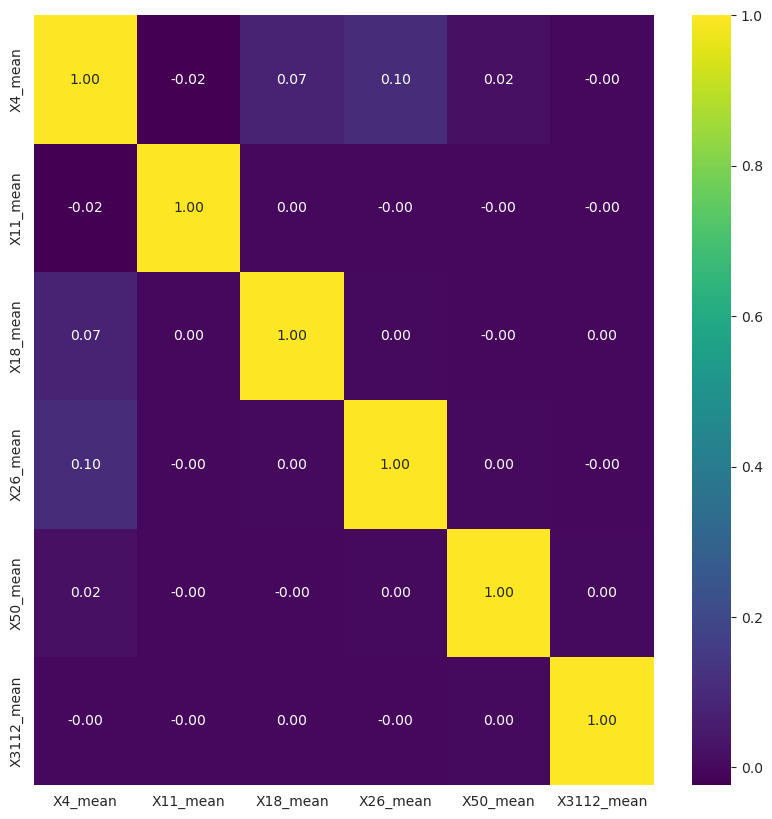

In [85]:
plot_corr(data, target)

In [86]:
# plot_hist_box(data, target, 'Histograms and Box Plots for Target Columns')

/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")
/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")
/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")
/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` wit

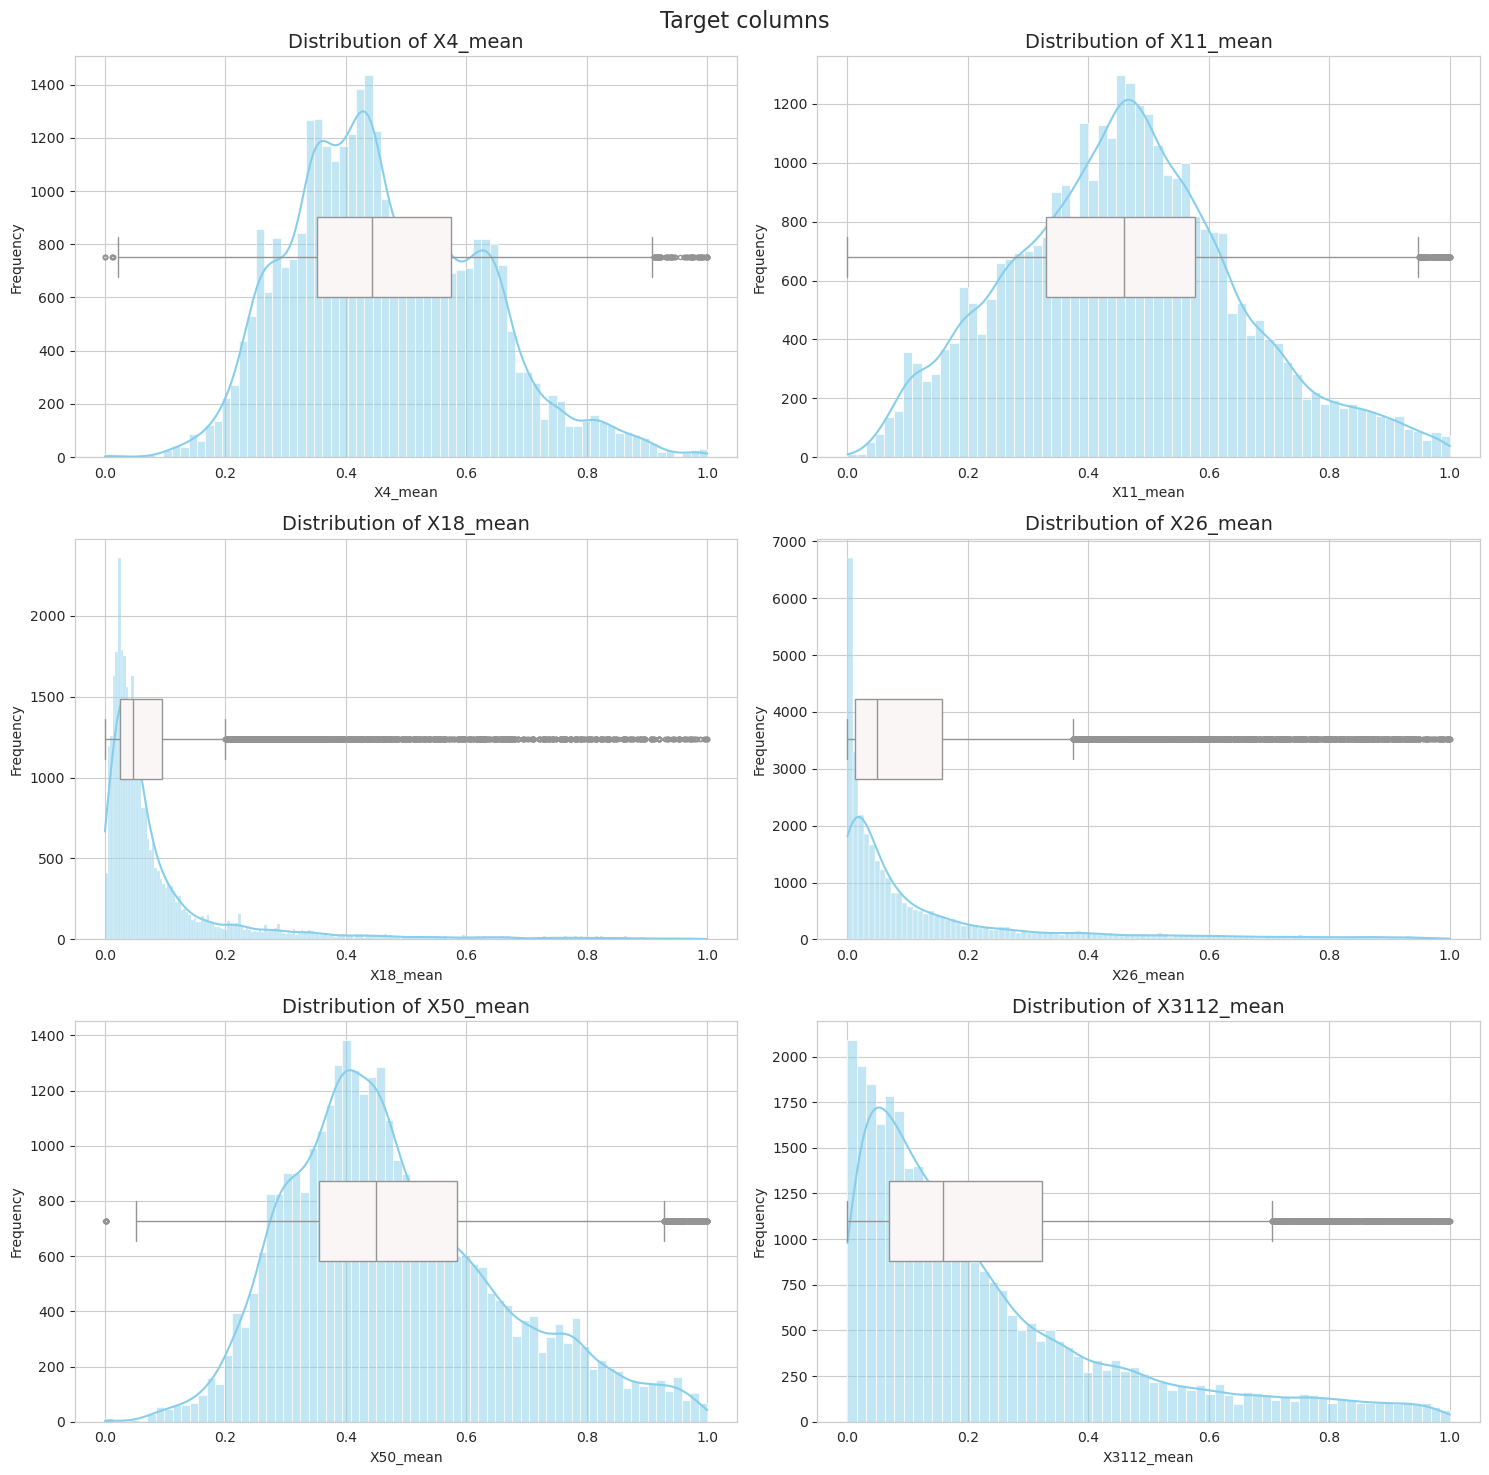

In [87]:
# plot histograms and box plots for target columns
plot_hist_box(normalize_columns(remove_outliers_iqr(data, target), target), target, 'Target columns')

In [88]:
calculate_skewness_kurtosis(normalize_columns(remove_outliers_iqr(data, target), target), target)

,Skewness,Kurtosis
X4_mean,0.44914,-0.093728
X11_mean,0.239429,-0.131991
X18_mean,3.286604,12.275182
X26_mean,2.222403,4.615305
X50_mean,0.634623,0.032038
X3112_mean,1.418172,1.391


#### Insights
* Damn the target columns are not balanced, except for the `X14_mean` column.
* Even after removing the outliers, the target columns are still not balanced, especially the `X18_mean`, `X26_mean`, `X3112_mean` columns.
* It costs around 20 thousand samples to remove the outliers from the target columns (around 16k for `X18_mean`, `X26_mean`, `X3112_mean`).
* Is the cost of the samples worth it? Are there any other ways to balance the target columns?

#### Ideas
* Maybe remove the `X18_mean`, `X26_mean`, `X3112_mean` columns.
* Try to unskew the data of the target columns using log or box-cox transformation.

#### 

### X4, X11, X50

these columns are not really balanced, but it gets better after removing the outliers.

In [89]:
balanced_target = ['X4_mean', 'X11_mean', 'X50_mean']

In [90]:
calculate_skewness_kurtosis(data, balanced_target)

,Skewness,Kurtosis
X4_mean,0.790196,57.046381
X11_mean,117.468777,13819.280275
X50_mean,117.738198,13862.583436


In [91]:
# plot_hist_box(data, balanced_target, 'Balanced Target Columns')

In [92]:
calculate_skewness_kurtosis(remove_outliers_iqr(data, balanced_target), balanced_target)

,Skewness,Kurtosis
X4_mean,0.334585,-0.328539
X11_mean,0.291846,-0.180862
X50_mean,0.606403,-0.015939


/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")
/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")
/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")


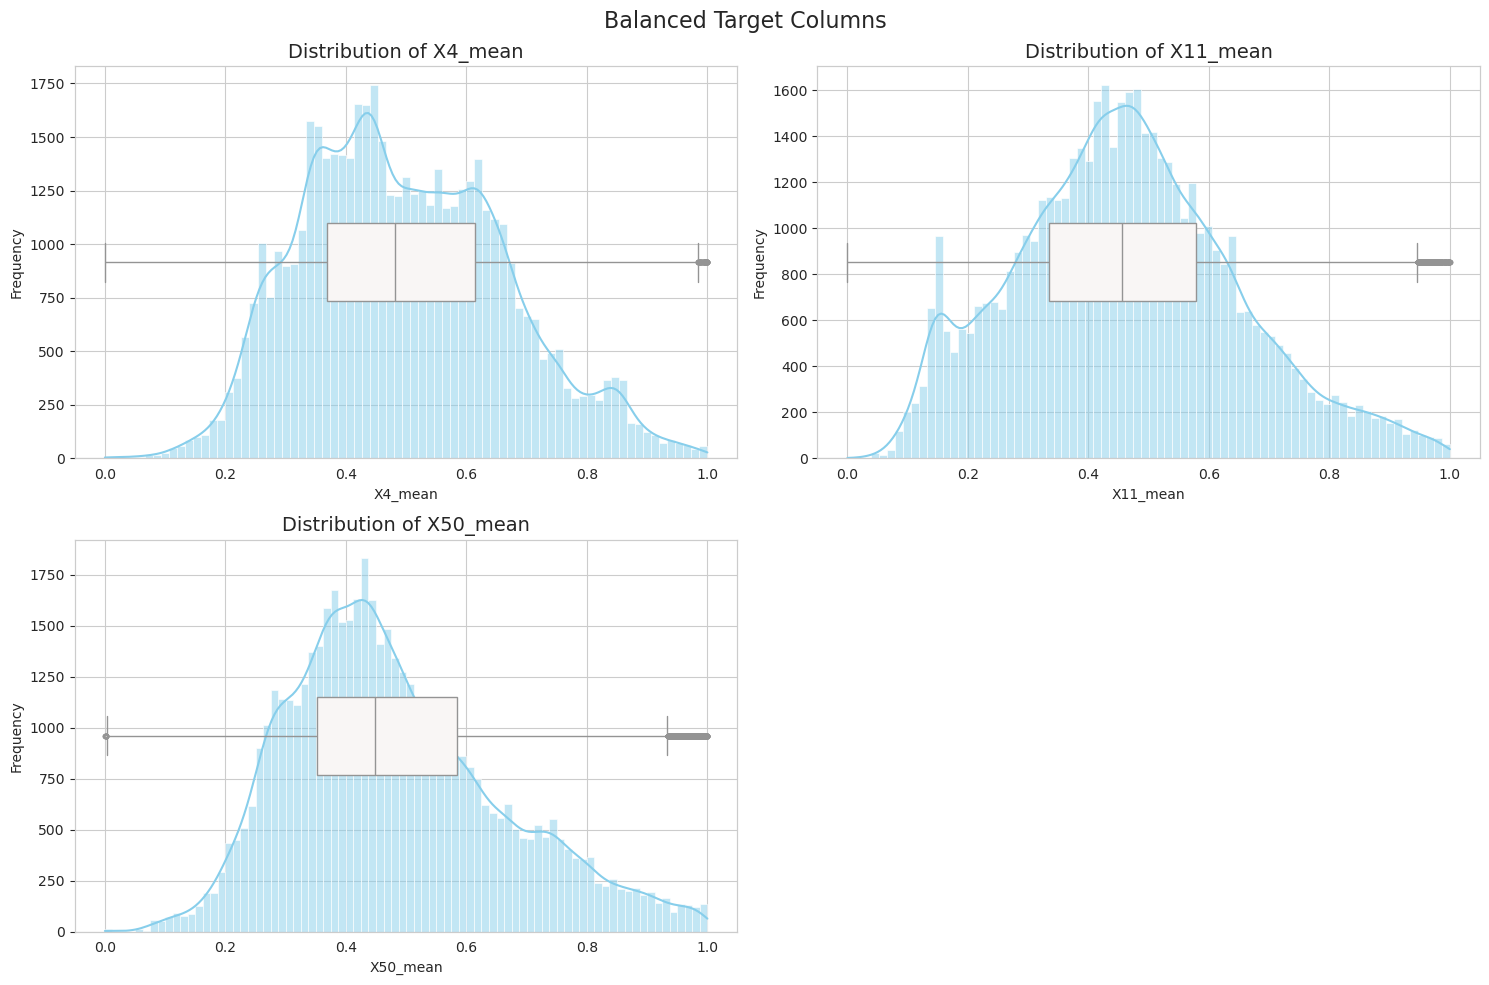

In [93]:
plot_hist_box(normalize_columns(remove_outliers_iqr(data, balanced_target), balanced_target), balanced_target, 'Balanced Target Columns')

In [94]:
normalize_columns(remove_outliers_iqr(data, balanced_target), balanced_target)[balanced_target].describe().T.style.background_gradient(cmap='viridis', low=0.5, high=0.5)

,count,mean,std,min,25%,50%,75%,max
X4_mean,50049.000000,0.496868,0.168029,0.000000,0.368680,0.480936,0.615116,1.000000
X11_mean,50049.000000,0.462297,0.184527,0.000000,0.333886,0.456198,0.578761,1.000000
X50_mean,50049.000000,0.478671,0.177865,0.000000,0.351761,0.448860,0.584523,1.000000


In [95]:
remove_outliers_iqr(data, balanced_target).shape

(50049, 176)

#### Insights
* Good distribution, with small number of outliers.

### X18, X26, X3112

These target columns are highly skewed even after removing the outliers. Further transformation is needed.

In [96]:
unbalanced_target = ['X18_mean', 'X26_mean', 'X3112_mean']

In [97]:
calculate_skewness_kurtosis(data, unbalanced_target)

,Skewness,Kurtosis
X18_mean,117.766224,13867.005324
X26_mean,92.617978,10044.863791
X3112_mean,235.537107,55478.471521


In [98]:
# plot_hist_box(data, unbalanced_target, 'Unbalanced Target Columns')

/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")
/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")
/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")


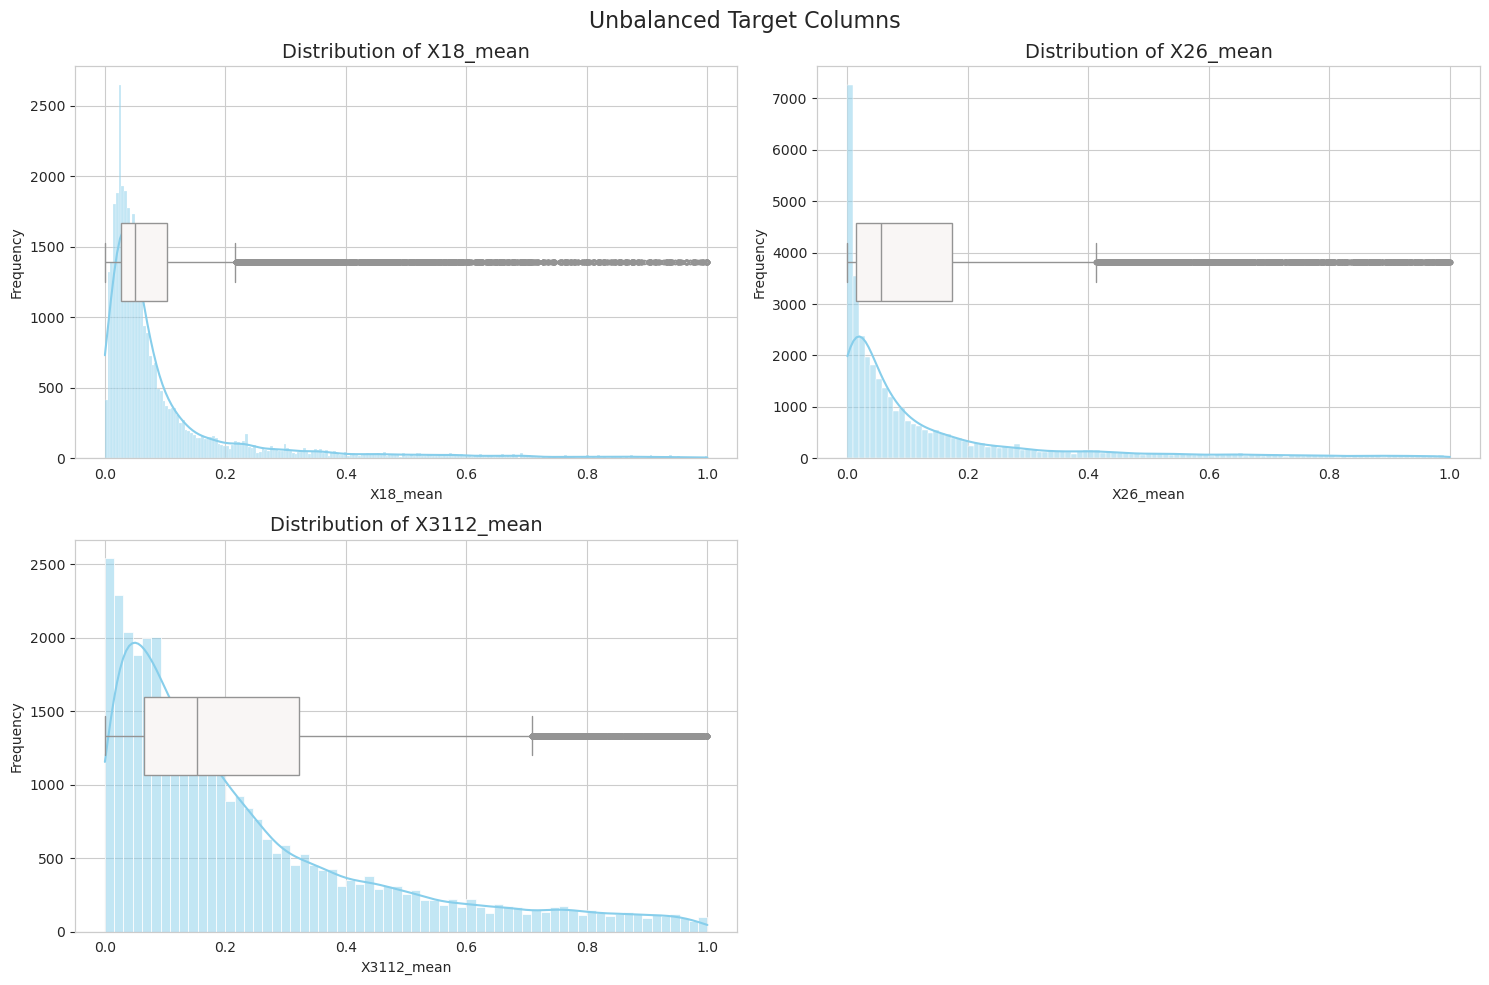

In [99]:
plot_hist_box(normalize_columns(remove_outliers_iqr(data, unbalanced_target), unbalanced_target), unbalanced_target, 'Unbalanced Target Columns')

In [100]:
calculate_skewness_kurtosis(normalize_columns(remove_outliers_iqr(data, unbalanced_target), unbalanced_target), unbalanced_target)

,Skewness,Kurtosis
X18_mean,3.048944,10.199193
X26_mean,2.107088,3.997177
X3112_mean,1.417735,1.352086


In [101]:
normalize_columns(remove_outliers_iqr(data, unbalanced_target), unbalanced_target)[unbalanced_target].describe().T.style.background_gradient(cmap='viridis', low=0.5, high=0.5)

,count,mean,std,min,25%,50%,75%,max
X18_mean,36808.000000,0.105190,0.152988,0.000000,0.026805,0.050185,0.102790,1.000000
X26_mean,36808.000000,0.145394,0.209040,0.000000,0.013948,0.056478,0.173594,1.000000
X3112_mean,36808.000000,0.231668,0.228442,0.000000,0.064917,0.153392,0.322281,1.000000


In [102]:
remove_outliers_iqr(data, unbalanced_target).shape

(36808, 176)

#### Insights
* Even after removing the outliers, it still has high skewness.
* It costs large sample to remove outliers of these columns

-> Transformation

/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")
/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")
/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")


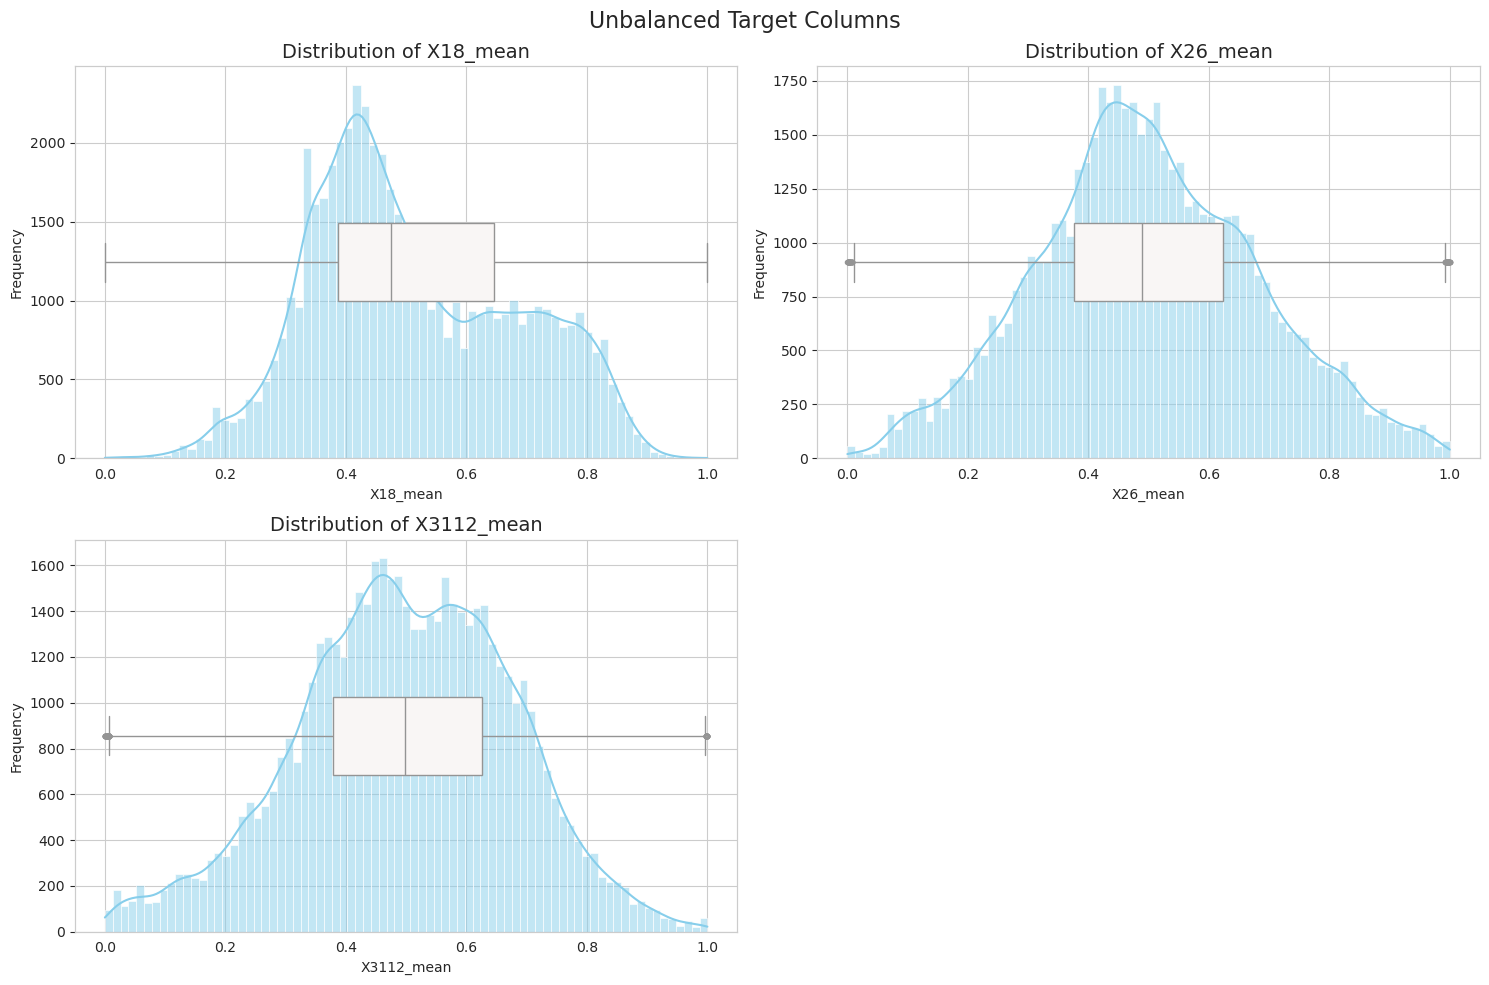

In [103]:
plot_hist_box(normalize_columns(remove_outliers_iqr(log_transform_columns(data, unbalanced_target), unbalanced_target), unbalanced_target), unbalanced_target, 'Unbalanced Target Columns')

In [104]:
normalize_columns(remove_outliers_iqr(log_transform_columns(data, unbalanced_target), unbalanced_target), unbalanced_target)[unbalanced_target].describe().T.style.background_gradient(cmap='viridis', low=0.5, high=0.5)

,count,mean,std,min,25%,50%,75%,max
X18_mean,54182.000000,0.511145,0.169711,0.000000,0.386215,0.474890,0.645835,1.000000
X26_mean,54182.000000,0.497679,0.183798,0.000000,0.376834,0.489221,0.622895,1.000000
X3112_mean,54182.000000,0.496950,0.179054,0.000000,0.377889,0.498752,0.625140,1.000000


In [105]:
remove_outliers_iqr(log_transform_columns(data, unbalanced_target), unbalanced_target).shape

(54182, 176)

#### Insights
* The log transformation is enough to unskew the data of these columns.
* There is only a small amount of samples that are removed after the transformation.

### Auxillary Target Columns

In [106]:
aux_target

['X4_sd', 'X11_sd', 'X18_sd', 'X26_sd', 'X50_sd', 'X3112_sd']

In [107]:
data[aux_target].describe().T.style.background_gradient(cmap='viridis', low=0.5, high=0.5)

,count,mean,std,min,25%,50%,75%,max
X4_sd,39148.000000,0.007833,0.012046,0.000000,0.003292,0.004996,0.007774,0.284052
X11_sd,39148.000000,1.073573,4.098486,0.000000,0.174866,0.357821,1.092862,515.672017
X18_sd,39148.000000,16.003476,881.605417,0.000000,0.029985,0.095136,0.330147,63535.386846
X26_sd,39148.000000,110.733150,8361.855750,0.000000,0.042226,0.238664,1.516574,739701.798818
X50_sd,39148.000000,0.075108,0.159520,0.000000,0.017207,0.033162,0.082851,9.729029
X3112_sd,39148.000000,453.017146,4196.228211,0.000000,17.259899,63.322952,226.990400,387491.201058


In [108]:
calculate_skewness_kurtosis(data, aux_target)

,Skewness,Kurtosis
X4_sd,6.821683,72.95033
X11_sd,101.548176,12696.568385
X18_sd,63.238928,4182.948218
X26_sd,88.37874,7813.973291
X50_sd,30.810139,1738.670931
X3112_sd,58.121349,4469.654897


In [109]:
# plot_hist_box(data, aux_target, 'Auxiliary Target Columns')

In [110]:
len(data)

55489

/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")
/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")
/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")


/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")
/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")
/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")


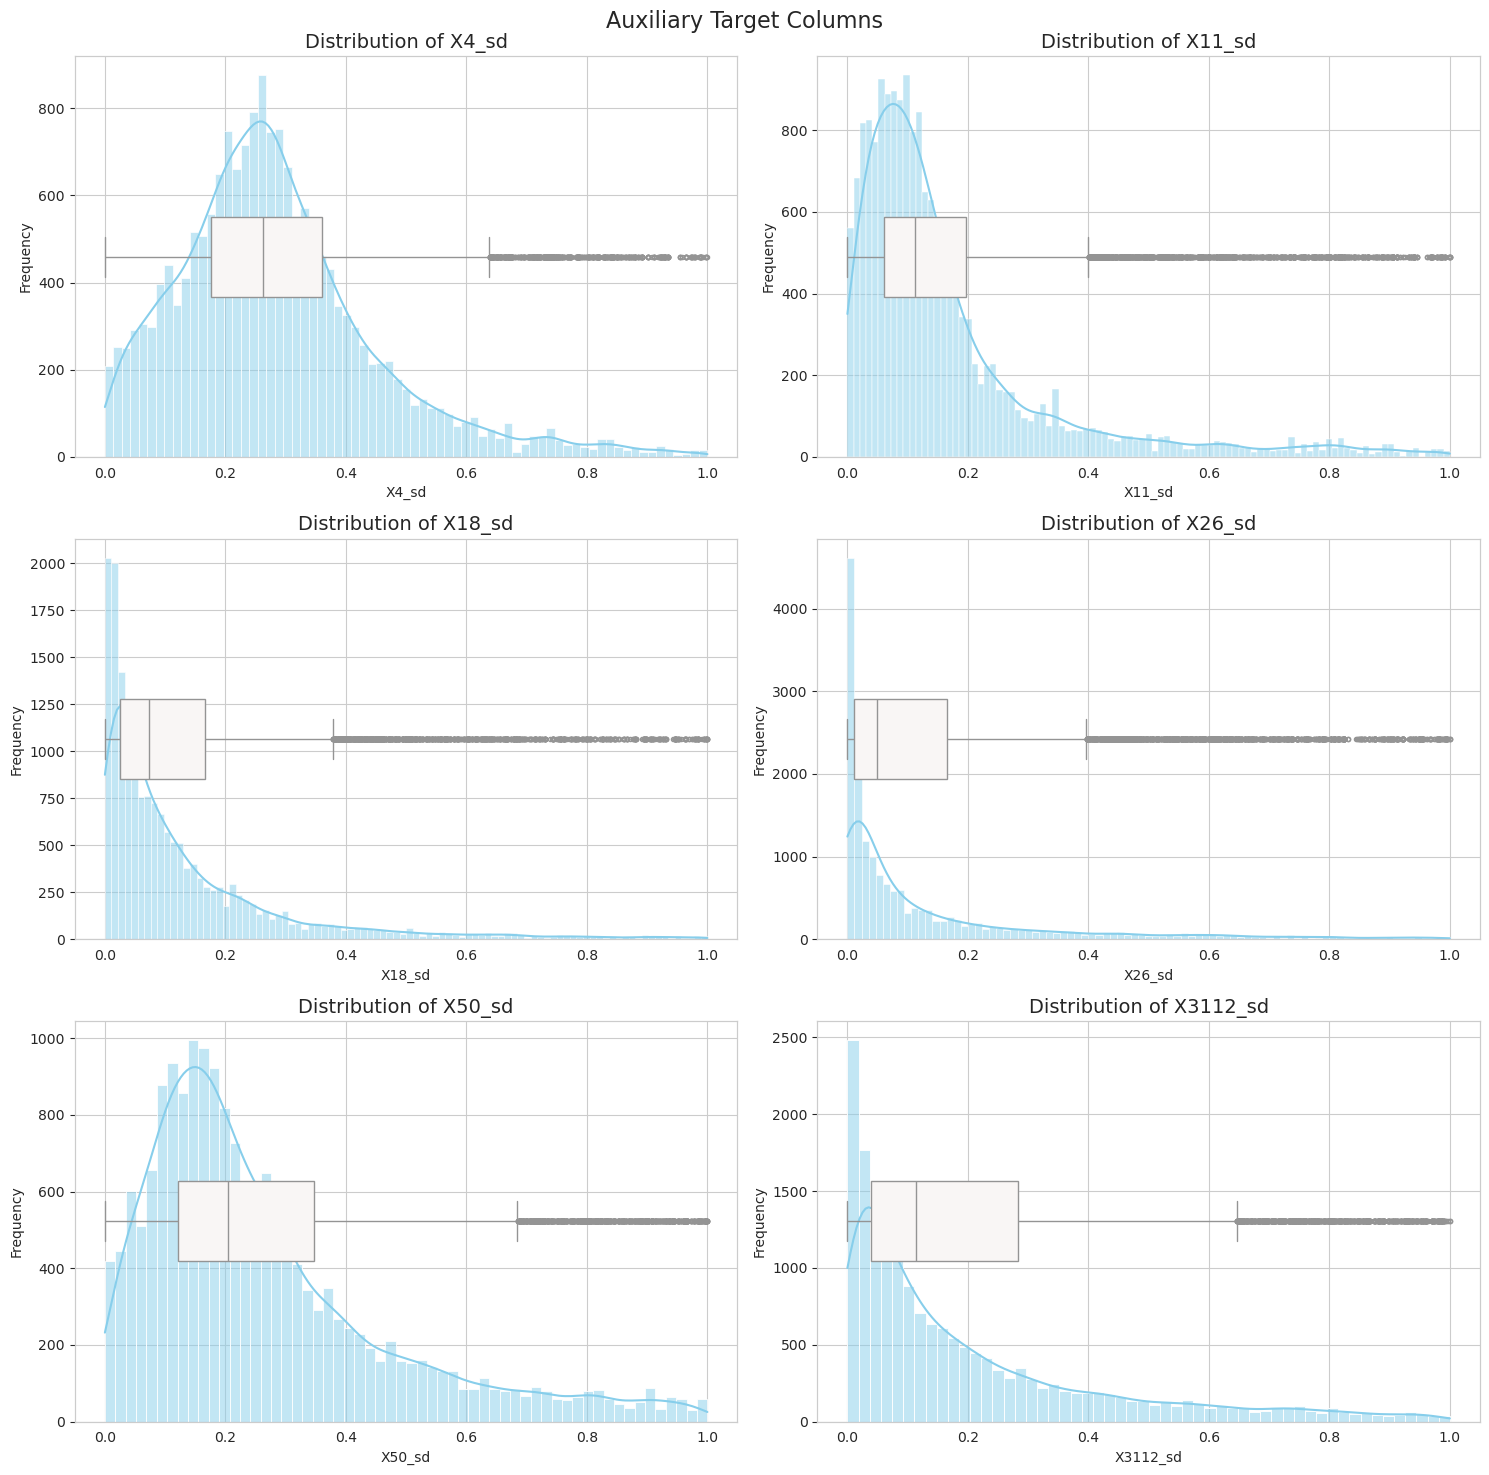

In [111]:
plot_hist_box(normalize_columns(remove_outliers_iqr(data, aux_target), aux_target), aux_target, 'Auxiliary Target Columns')

In [112]:
remove_outliers_iqr(data, aux_target).shape

(17782, 176)

### Applying Ideas for The Target Columns

            Skewness  Kurtosis
X4_mean     0.351589  -0.34496
X11_mean    0.281097 -0.182051
X18_mean    0.346898 -0.721503
X26_mean    0.158061 -0.233245
X50_mean    0.607862 -0.020611
X3112_mean  -0.16457 -0.181052


/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")
/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")
/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=column, ax=ax2, width=0.2, fliersize=3, palette="vlag")
/tmp/ipykernel_1056843/1294002748.py:47: FutureWarning: 

Passing `palette` wit

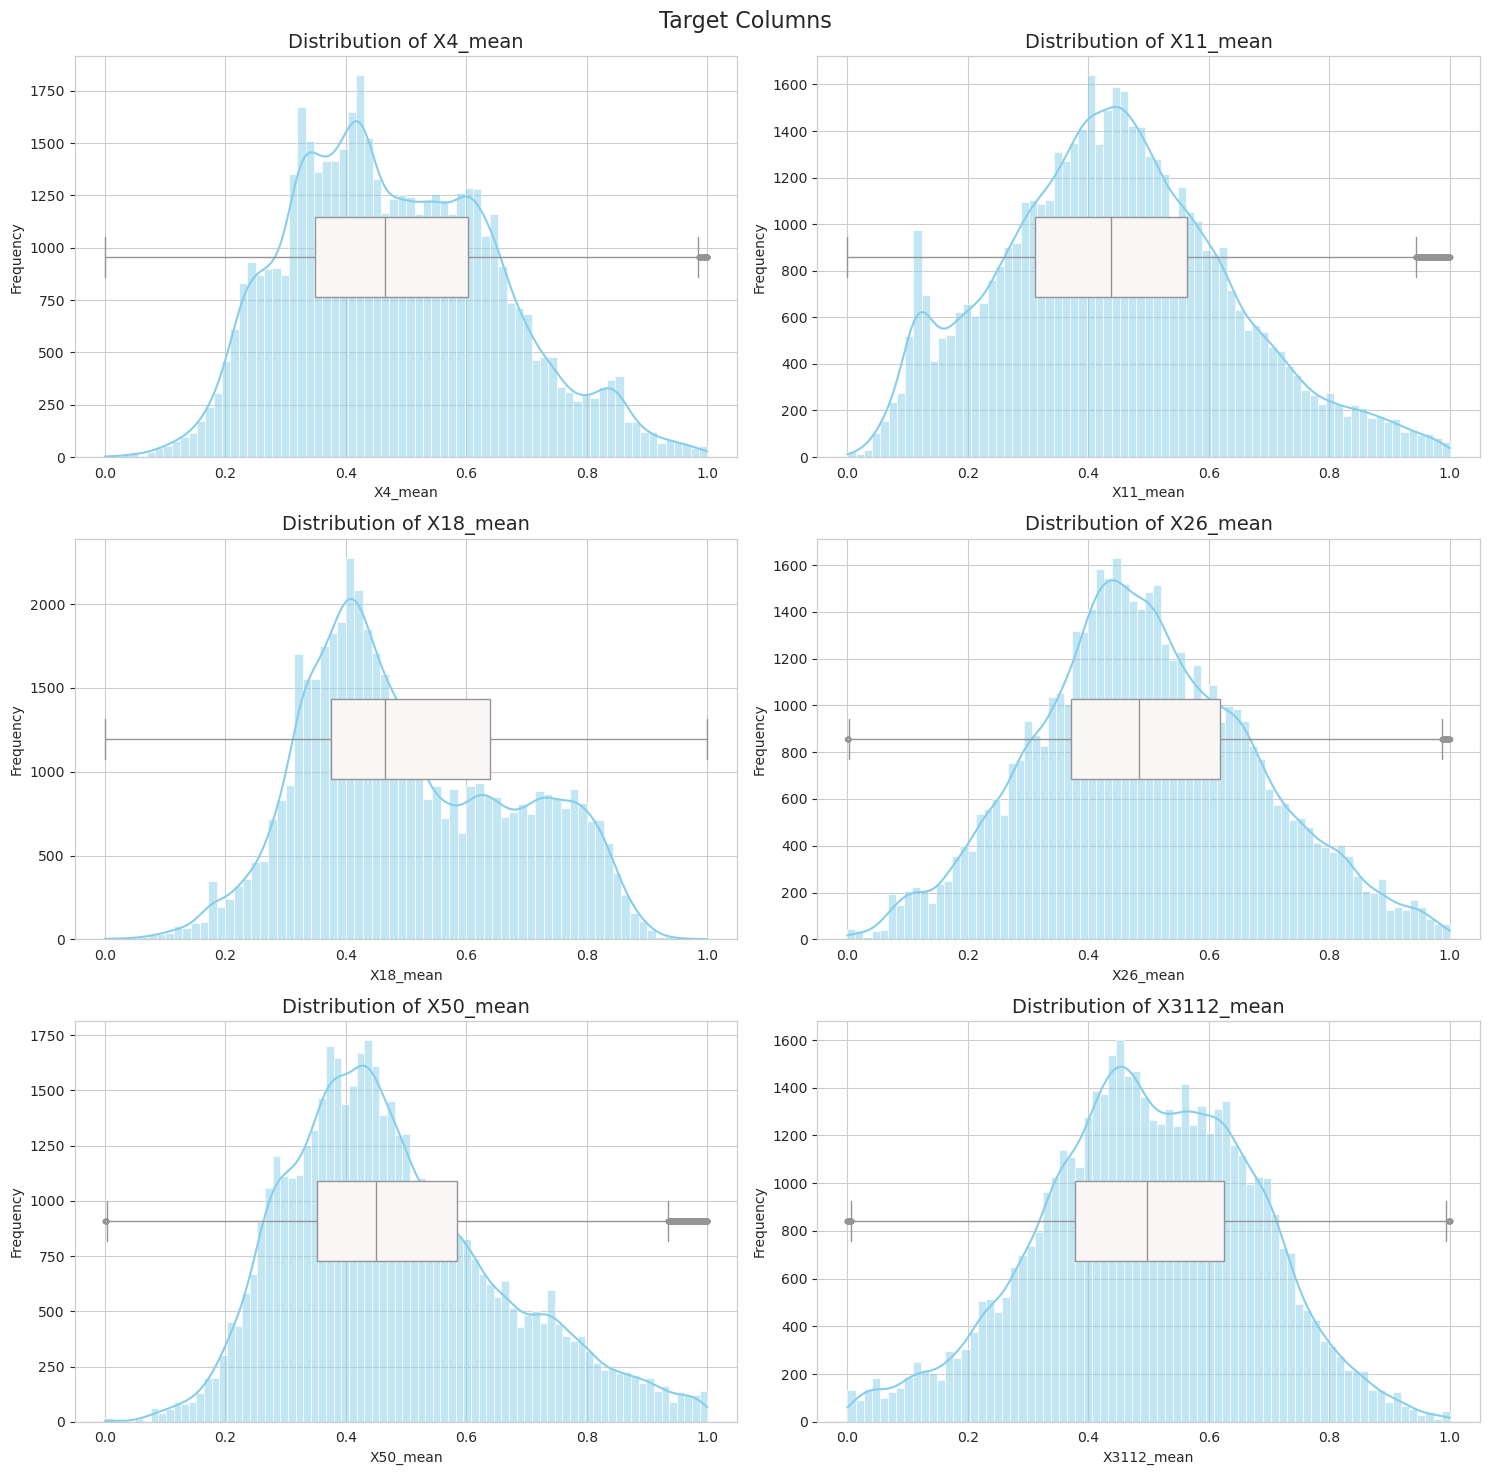

(49051, 176)

In [113]:
data_cleaned = data.copy()

# transforming the unbalanced target columns
data_cleaned = log_transform_columns(data, unbalanced_target)

# remove outliers from the unbalanced target columns
data_cleaned = remove_outliers_iqr(data_cleaned, target)

# normalize the target columns
minmax_scaler = MinMaxScaler()
data_cleaned[target] = minmax_scaler.fit_transform(data_cleaned[target])

# print the curtosis and skewness
print(calculate_skewness_kurtosis(data_cleaned, target))

# plot the histograms and box plots for the target columns
plot_hist_box(data_cleaned, target, 'Target Columns')

data_cleaned.shape

In [114]:
data_cleaned[target].describe().T.style.background_gradient(cmap='viridis', low=0.5, high=0.5)

,count,mean,std,min,25%,50%,75%,max
X4_mean,49051.000000,0.481479,0.172761,0.000000,0.349205,0.464250,0.603482,1.000000
X11_mean,49051.000000,0.443208,0.191207,0.000000,0.310906,0.437390,0.563810,1.000000
X18_mean,49051.000000,0.503257,0.173540,0.000000,0.374461,0.465559,0.638747,1.000000
X26_mean,49051.000000,0.493932,0.184058,0.000000,0.371507,0.483571,0.617802,1.000000
X50_mean,49051.000000,0.479098,0.177703,0.000000,0.352146,0.449282,0.585146,1.000000
X3112_mean,49051.000000,0.496175,0.179184,0.000000,0.377437,0.496981,0.625359,1.000000


In [115]:
# export data
data_cleaned.to_csv('train.csv', index=False)

In [116]:
# export test data
test_data.to_csv('test.csv', index=False)

In [117]:
# apply inverse transform to the target columns
result = pd.read_csv('results.csv')
result[target] = minmax_scaler.inverse_transform(result[target])

# exponentiate the unbalanced target columns
result[unbalanced_target] = np.exp(result[unbalanced_target])

# change the name of the columns
result.columns = result.columns.str.replace('_mean', '')

# export the results
result.to_csv('submission.csv', index=False)

FileNotFoundError: [Errno 2] No such file or directory: 'results.csv'